In [31]:
import cv2 as cv
import dlib
import matplotlib.pyplot as plt

()


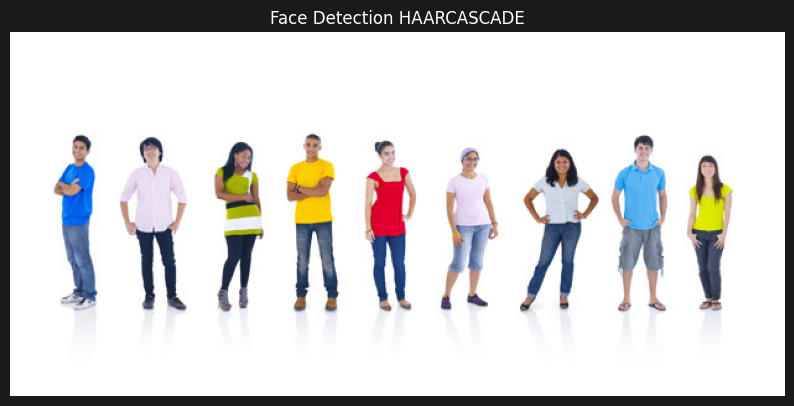

In [ ]:
from pathlib import Path

# Get repo root for file paths
notebook_dir = Path.cwd()
repo_root = Path(__file__).parent.parent if hasattr(__file__, '__len__') else notebook_dir
while repo_root.name != 'Machine_Learning' and repo_root.parent != repo_root:
    repo_root = repo_root.parent
course_materials = repo_root / 'computer_vision' / 'Course_Materials'

#Haarcascade
img4=cv.imread(str(course_materials / 'Images' / 'people3.jpg'))
hr=cv.CascadeClassifier(str(course_materials / 'Cascades' / 'haarcascade_frontalface_default.xml'))
det = hr.detectMultiScale(img4, scaleFactor=1.1, minNeighbors=8)

for (x,y,w,h) in det:
    cv.rectangle(img4, (x, y), (x + w, y + h), (0, 0, 255), 2)

i=cv.CascadeClassifier(str(course_materials / 'Cascades' / 'haarcascade_eye.xml'))
idet=i.detectMultiScale(img4, scaleFactor=1.1, minNeighbors=6, minSize=(23,23), maxSize=(75,75))
print(idet)
for (x,y,w,h) in idet:
    cv.rectangle(img4, (x, y), (x + w, y + h), (67, 200, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
plt.title("Face Detection HAARCASCADE")
plt.axis('off')
plt.show()

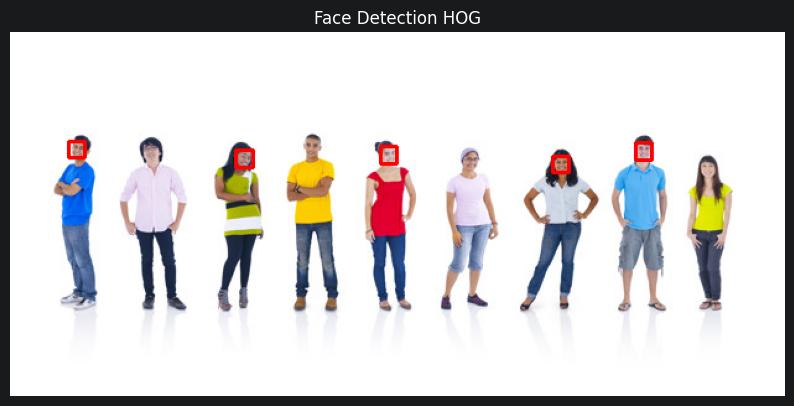

In [ ]:
heh=dlib.get_frontal_face_detector()
img4 = cv.imread(str(course_materials / 'Images' / 'people3.jpg'))
deh=heh(img4, 4)

for face in deh:
    l,t,r,b=face.left(), face.top(), face.right(), face.bottom()
    cv.rectangle(img4, (l, t), (r,b), (0, 0, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(img4, cv.COLOR_BGR2RGB))
plt.title("Face Detection HOG")
plt.axis('off')
plt.show()

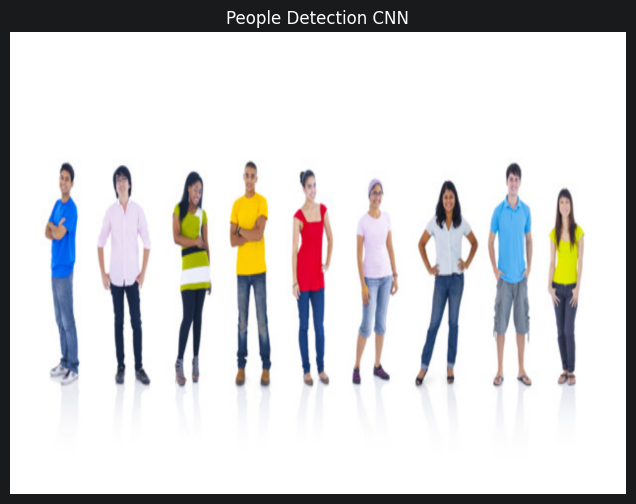

In [ ]:
mim=cv.imread(str(course_materials / 'Images' / 'people3.jpg'))
mim=cv.resize(mim, (1000,750))
cn=dlib.cnn_face_detection_model_v1(str(course_materials / 'Weights' / 'mmod_human_face_detector.dat'))
cet=cn(mim, 3)

for face in cet:
    l,t,r,b,c= face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom(), face.confidence
    cv.rectangle(mim, (l,t), (r,b), (0,0,255),2)
    print(face.confidence)
plt.figure(figsize=(10, 6))
plt.imshow(cv.cvtColor(mim, cv.COLOR_BGR2RGB))
plt.title("People Detection CNN")
plt.axis('off')
plt.show()